# XDM и MFEX
 Обычно сначала строят модель, а потом объясняют её поведение. Мы делаем иначе. Мы сначала смотрим на саму таблицу и пытаемся понять, какие признаки в ней действительно выглядят важными. Такой подход называется XDM, то есть объяснимый анализ данных.

<p align="center">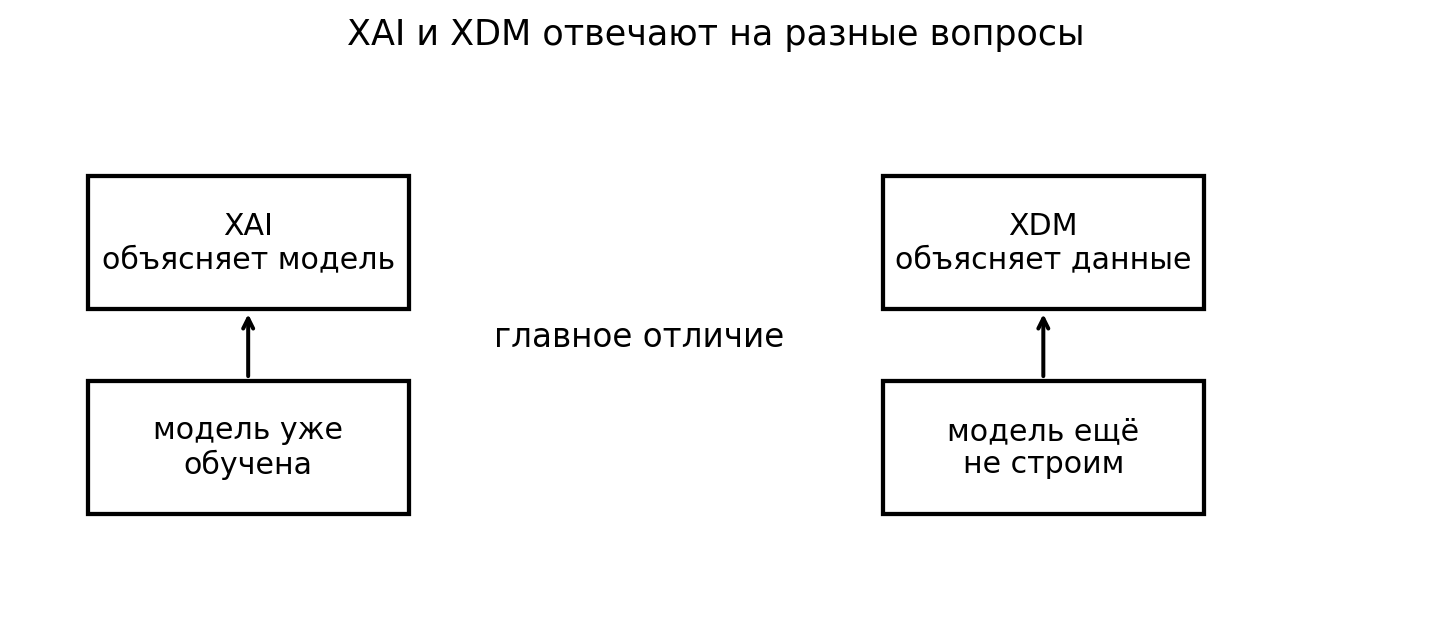</p>

<p align="center"><b>Рисунок 1. XAI объясняет модель, XDM объясняет данные до модели</b></p>

## Что такое XDM

XDM означает объяснимый анализ данных. В этой работе это анализ таблицы до обучения модели.

Таблица состоит из строк и столбцов. Строка означает один объект. В медицинском датасете это может быть один пациент или один образец ткани. В ESG-датасете это может быть компания, год или отчёт. Столбцы называются признаками. Целевая переменная показывает то, что мы хотим объяснить. Например, класс опухоли, риск заболевания, уровень ESG-рейтинга или факт финансового события.

XDM отвечает на простой вопрос: какие признаки в самой таблице сильнее всего связаны с целевой переменной и почему.

## Что такое MFEX

MFEX не является моделью. Это не классификатор, не нейронная сеть и не готовая кнопка из библиотеки.

MFEX является протоколом. Протокол означает порядок действий. Мы берём таблицу, считаем несколько простых оценок важности признаков, переводим их в ранги и собираем общий список. После этого проверяем, оказался ли общий список лучше случайного выбора признаков.

Важный принцип: мы не обучаем предсказательную модель. Нет эпох, нет подбора весов, нет функции предсказания. Мы работаем с самой структурой данных.

<p align="center">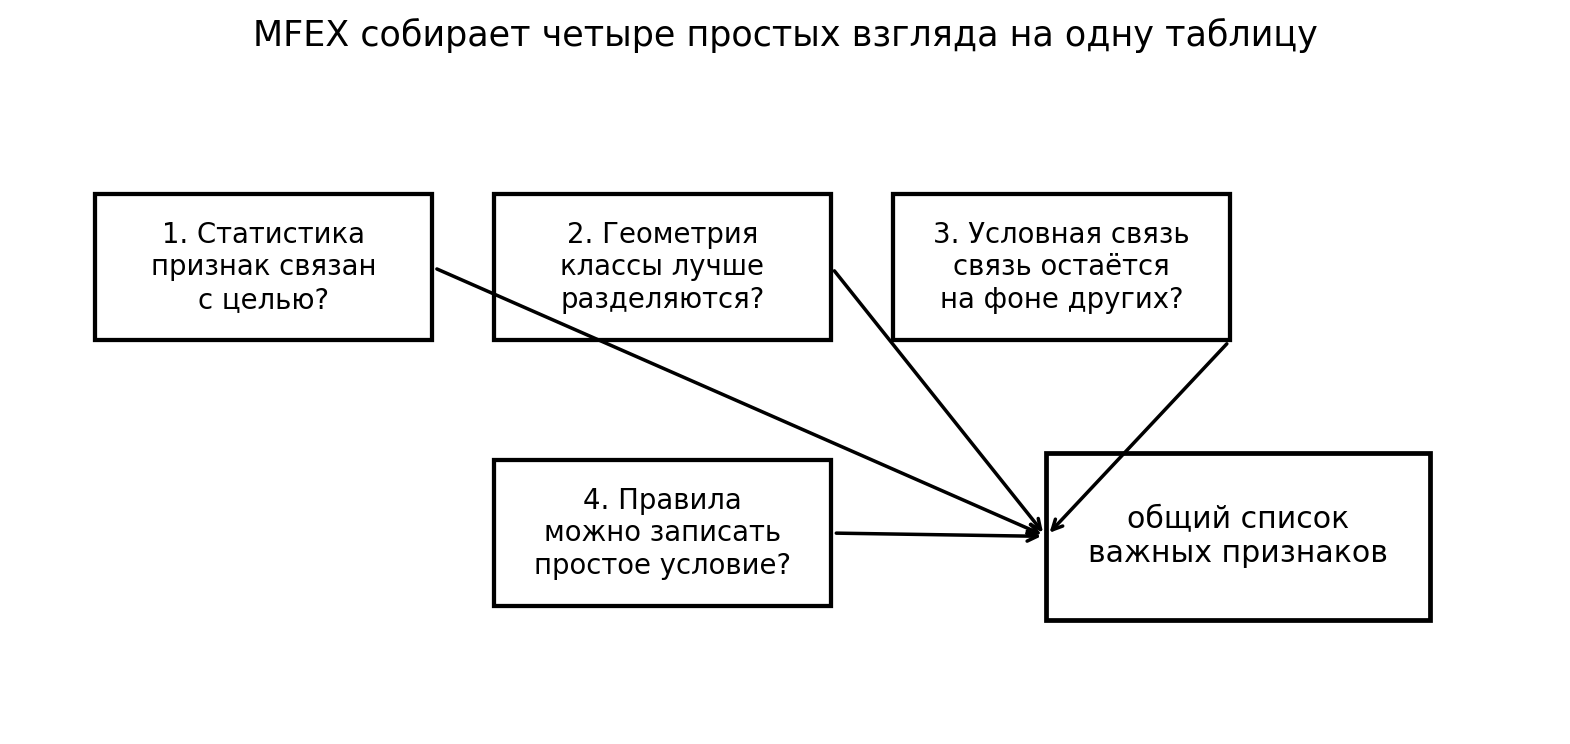</p>

<p align="center"><b>Рисунок 2. Четыре источника важности в MFEX</b></p>

## Что именно нужно вытащить из датасета

Когда студент получает свой датасет, он должен не просто запустить код. Он должен понять, что находится в таблице.

Сначала нужно определить цель. Это столбец, который объясняется. Затем нужно определить признаки. Это остальные столбцы, по которым мы ищем связь с целью. После этого проверяются размер таблицы, пропуски, баланс классов и типы признаков.

В конце из датасета нужно получить не один красивый график, а конкретный набор результатов: top-признаки по каждому источнику, общий top по консенсусу, значение MFF-NoFit, устойчивость признаков и несколько простых правил.

<p align="center">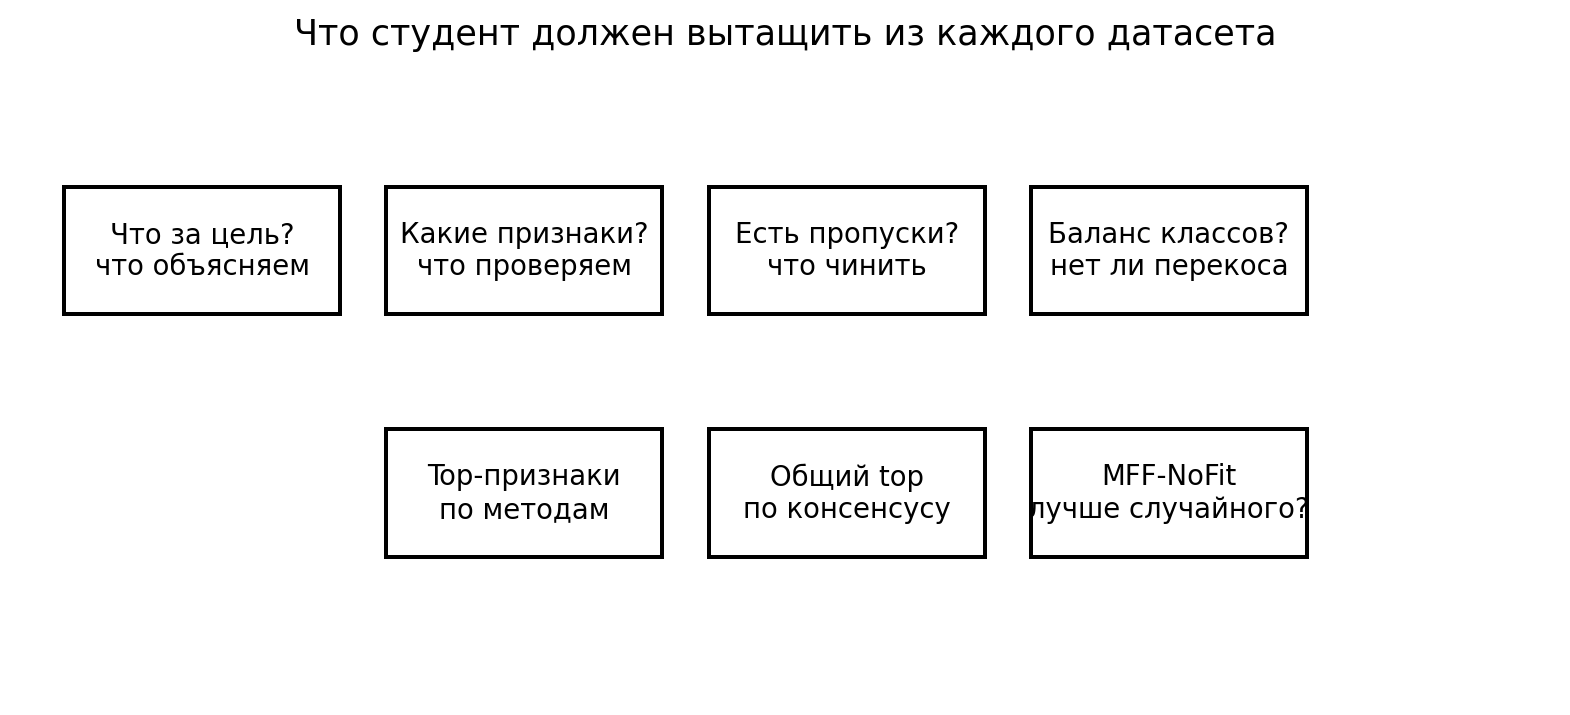</p>

<p align="center"><b>Рисунок 3. Минимум, который нужно извлечь из каждого датасета</b></p>

## Первый взгляд: статистическая связь

Статистическая связь показывает, меняется ли признак вместе с целевой переменной.

Пример из медицины. Если значения признака у доброкачественных и злокачественных образцов сильно различаются, такой признак получает высокий статистический вклад. Это ещё не доказывает причину болезни. Это только говорит, что в таблице есть заметная связь.

В практическом Colab для простоты используется ранговая связь и различие средних между классами. Студенту важно понять смысл: мы ищем признаки, которые явно отличаются у разных классов.

## Второй взгляд: геометрия

Геометрия смотрит на таблицу как на облако точек.

Если признак полезен, то по нему объекты разных классов становятся дальше друг от друга, а объекты одного класса остаются ближе. Поэтому геометрический источник проверяет, ухудшается ли разделение классов, когда мы убираем признак.

Это не классификатор. Здесь никто не учится предсказывать класс. Мы просто считаем расстояния между объектами.

## Третий взгляд: условная связность

Иногда признак выглядит важным только потому, что повторяет другой признак. Например, площадь и периметр объекта могут быть очень похожими по смыслу. Тогда простая связь с целью может завышать важность.

Условная связность проверяет, остаётся ли связь признака с целью на фоне остальных переменных. Это не доказательство причинности. Это более осторожная проверка: признак всё ещё связан с целью, когда мы учитываем общую структуру таблицы.

## Четвёртый взгляд: правила

Правила нужны, чтобы результат можно было объяснить словами.

Например, правило может звучать так: если значение признака попадает в высокий интервал, то доля одного класса внутри такой группы заметно выше. Такое правило не является диагнозом и не является управленческим решением. Оно показывает, что внутри таблицы есть понятная подгруппа.

Этот блок особенно важен для защиты. По нему студент может объяснить результат не только числами, но и человеческим языком.

## Что такое консенсус

Разные методы часто дают разные списки признаков. Это нормально. Один метод видит статистическую связь, другой видит геометрию, третий видит правила.

Консенсус нужен, чтобы получить общий список. Каждый метод переводит признаки в ранги. Ранг 1 означает самый важный признак. Затем для каждого признака берётся средний или медианный ранг. Чем ниже итоговый ранг, тем выше место признака в общем списке.

Если признак высоко стоит сразу в нескольких источниках, он считается более надёжным. Если он высоко стоит только в одном источнике, его нужно обсуждать отдельно.

## Что такое MFF-NoFit

MFF-NoFit отвечает на простой вопрос: наш общий top признаков лучше случайного набора или нет.

Мы берём top-k признаков по консенсусу и считаем, насколько хорошо они сохраняют различие между классами по расстояниям. Потом много раз берём случайные k признаков и считаем то же самое. Если наш top-k заметно лучше случайного фона, значит объяснение не случайное.

Это снова не модель. Мы не измеряем accuracy, не строим прогноз и не обучаем алгоритм. Мы только проверяем, сохраняет ли выбранный набор признаков структуру цели.

<p align="center">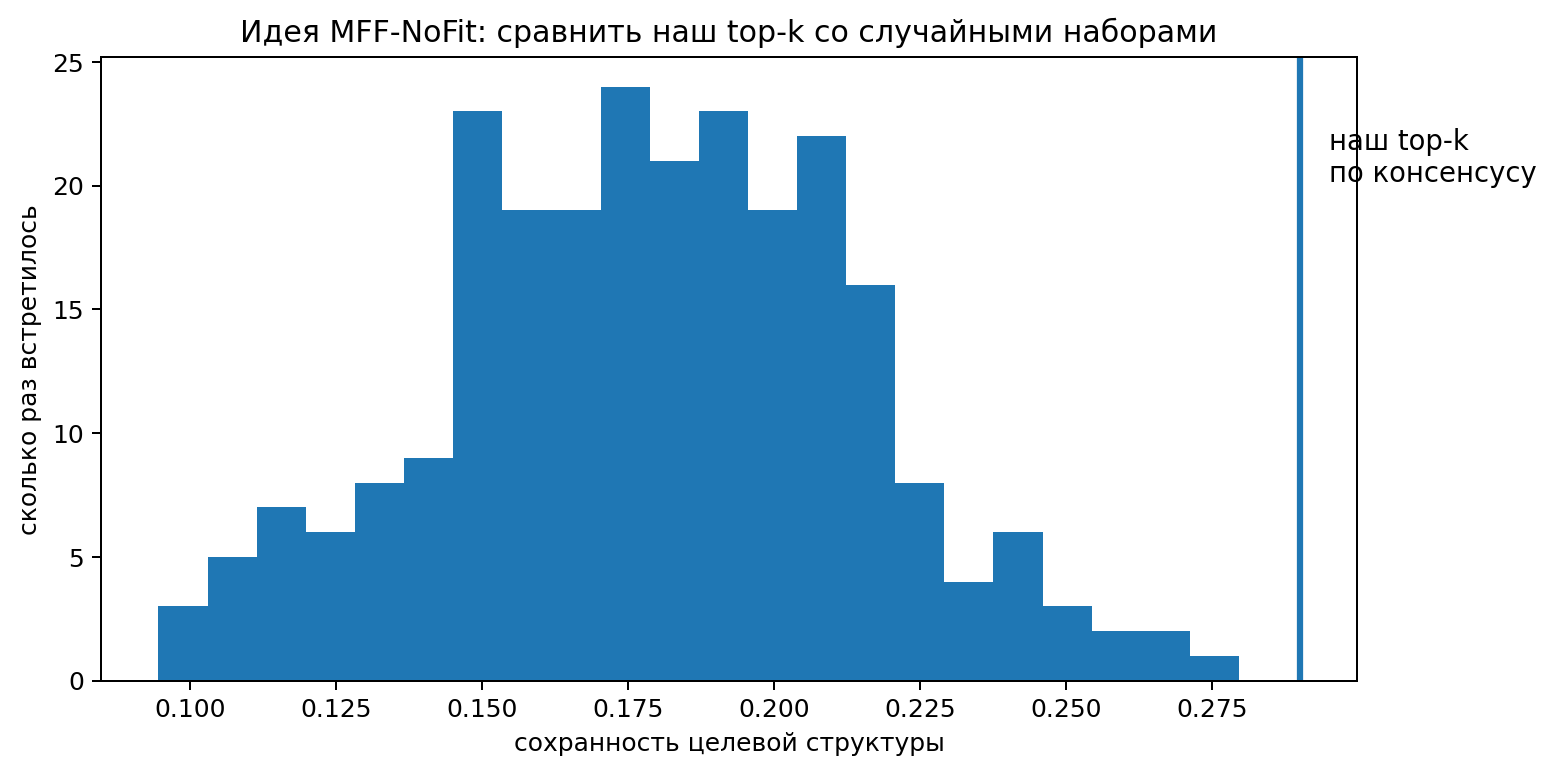</p>

<p align="center"><b>Рисунок 4. MFF-NoFit сравнивает консенсусный top-k со случайными наборами</b></p>

## Что студент должен написать в конце своего ноутбука

В конце практического Colab студент должен написать короткий вывод.

Нужно указать, какой датасет был взят, что является целевой переменной, сколько объектов и признаков в таблице, какие признаки вошли в общий top-5, положительный ли MFF-NoFit, какие признаки оказались устойчивыми и какие правила можно объяснить словами.

Самое важное: нельзя писать только «код запустился». Нужно объяснить, что именно было найдено в данных.

## Мини-словарь

**Датасет** — таблица данных.

**Объект** — одна строка таблицы.

**Признак** — один столбец, по которому мы изучаем объект.

**Целевая переменная** — столбец, который мы объясняем.

**Ранг** — место признака в списке важности.

**Консенсус** — общий список, собранный из нескольких методов.

**MFF-NoFit** — проверка, что выбранные признаки лучше случайных признаков сохраняют структуру цели.

**No-fit** — режим без обучения предсказательной модели.